### Distribution of degree

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
def log_chart(df, str):
    labels = [f"{int(row['min_degree'])}-{int(row['max_degree'])}" for _, row in df.iterrows()]

    plt.figure(figsize=(6,4))
    bars = plt.bar(range(len(df)), df['nodeCount'], color='teal', edgecolor='black', alpha=0.8)

    plt.xticks(range(len(df)), labels, rotation=45)
    plt.yscale('log')
    plt.xlabel('Intervalo de Grau')
    plt.ylabel(f'Quantidade de {str} (Log)')
    plt.title(f'Histograma de Graus (escala log) - {str}')

    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=9)

    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

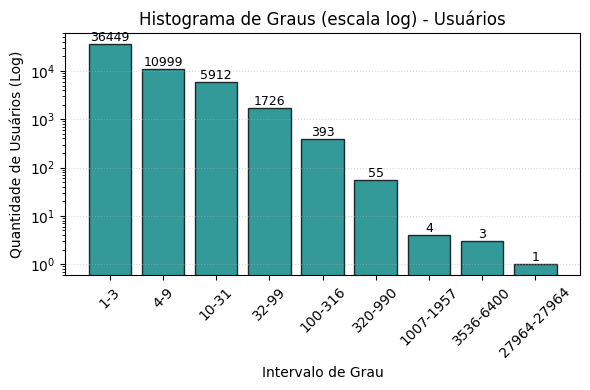

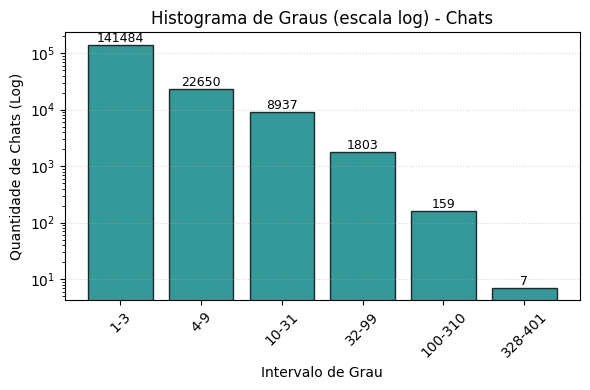

In [2]:
df1 = pd.read_csv("preprocess_data/degree_component_distribution/users_degree.csv")
df2 = pd.read_csv("preprocess_data/degree_component_distribution/chats_degree.csv")
log_chart(df1, "Usuários")
log_chart(df2, "Chats")

In [3]:
def linear_chart(df, label_str):
    if 'min_degree' in df.columns:
        labels = [f"{int(row['min_degree'])}-{int(row['max_degree'])}" for _, row in df.iterrows()]
    else:
        max_val = df['maxDeg'].max()
        step = max_val / 10
        labels = [f"{int(i*step)}-{int((i+1)*step)}" for i in range(10)]

    plt.figure(figsize=(6,4))
    
    bars = plt.bar(range(len(df)), df['nodeCount'], color='steelblue', edgecolor='black', alpha=0.8)

    plt.xticks(range(len(df)), labels, rotation=45)
    
    plt.xlabel('Intervalo de Grau')
    plt.ylabel(f'Quantidade de {label_str}')
    plt.title(f'Histograma de Graus - {label_str} (escala linear)')

    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=10)

    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

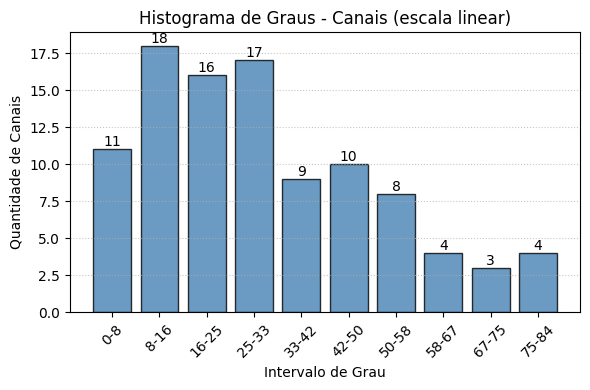

In [4]:
df_canais = pd.read_csv("preprocess_data/degree_component_distribution/channel_degree.csv")
linear_chart(df_canais, "Canais")

### Distribution of components

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_component_distribution(csv_file, title):
    df = pd.read_csv(csv_file)
    
    plt.figure(figsize=(6,4))
    
    labels = []
    for _, row in df.iterrows():
        min_s = int(row['minSizeInBin'])
        max_s = int(row['maxSizeInBin'])
        
        if min_s == max_s:
            labels.append(f"{min_s}")
        else:
            labels.append(f"{min_s}-{max_s}")
    
    bars = plt.bar(range(len(df)), df['quantityOfComponents'], color='teal', edgecolor='black')
    
    plt.yscale('log')
    
    plt.xticks(range(len(df)), labels, rotation=45, ha='right')
    plt.xlabel('Tamanho da Componente (número de vértices)')
    plt.ylabel('Quantidade de Componentes (Log)')
    plt.title(f'Histograma de Componentes (escala log) - {title}')
        
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom', fontsize=8)

    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

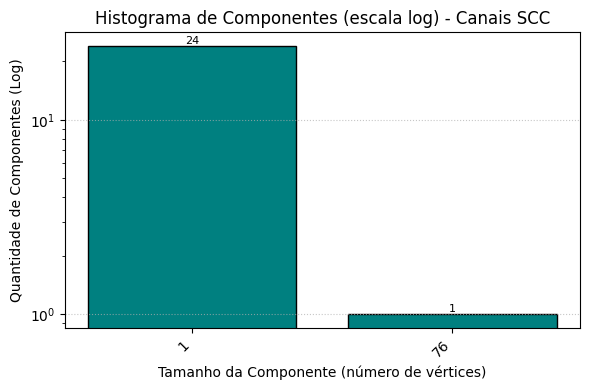

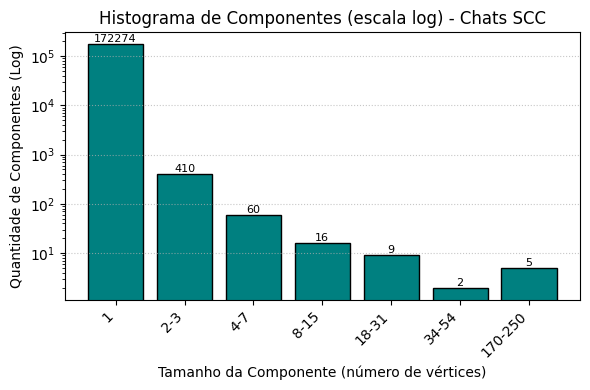

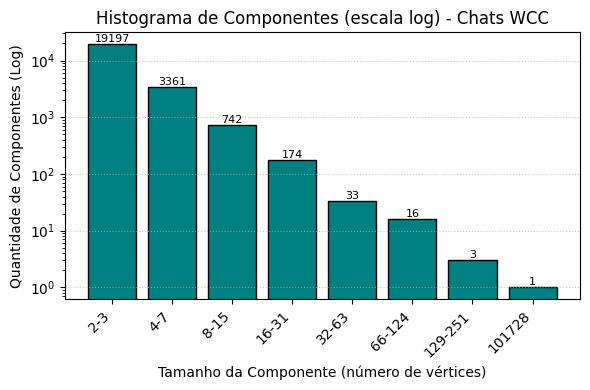

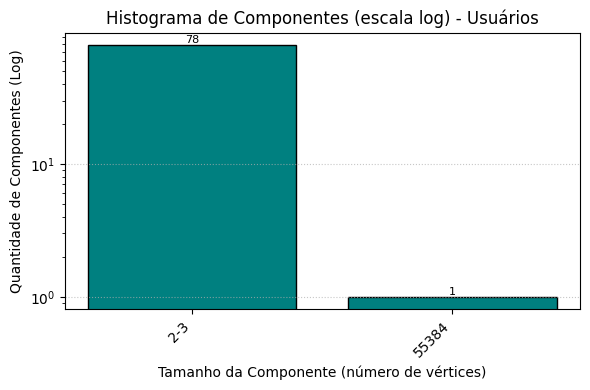

In [6]:
files = {
    "Canais SCC":   "preprocess_data/degree_component_distribution/channel_comp.csv",
    "Chats SCC":    "preprocess_data/degree_component_distribution/chats_comp.csv",
    "Chats WCC":    "preprocess_data/degree_component_distribution/chats_weak_comp.csv",
    "Usuários": "preprocess_data/degree_component_distribution/users_comp.csv"
}

for label, path in files.items():
    plot_component_distribution(path, label)